# OTT & Movie Ratings Trend Analysis

## Phase 4 — OTT Platform Integration

In [247]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Phase 4 started successfully!")

Phase 4 started successfully!


In [248]:
imdb_path = "../data/processed/imdb_movies_ratings_advanced.csv"

imdb = pd.read_csv(imdb_path)

print("IMDb Dataset Shape:", imdb.shape)

imdb.head()

IMDb Dataset Shape: (156380, 18)


,Title_ID,Content_Type,Title,Original_Title,Is_Adult,Release_Year,End_Year,Runtime_Minutes,Genres,IMDb_Rating,IMDb_Votes,Rating_Category,Decade,Popularity_Category,Log_Votes,Popularity_Score,Rating_Score,Content_Success_Score
0,tt0035423,movie,Kate & Leopold,Kate & Leopold,0,2001.0,NaN,118.0,"Comedy,Fantasy,Romance",6.4,94417,Average,2000.0,High,4.975055,0.659619,0.64,64.588572
1,tt0036606,movie,"Another Time, Another Place","Another Time, Another Place",0,1983.0,NaN,118.0,"Drama,War",6.4,386,Average,1980.0,Low,2.587711,0.129535,0.64,48.686060
2,tt0059325,movie,Born in '45,Jahrgang 45,0,1990.0,NaN,94.0,"Drama,Romance",6.5,297,Average,1990.0,Low,2.474216,0.104335,0.65,48.630052
3,tt0062181,movie,Hands Up!,Rece do góry,0,1981.0,NaN,80.0,Drama,6.5,513,Average,1980.0,Low,2.710963,0.156902,0.65,50.207064
4,tt0062336,movie,The Tango of the Widower and Its Distorting Mi...,El tango del viudo y su espejo deformante,0,2020.0,NaN,70.0,"Drama,Mystery",6.3,297,Average,2020.0,Low,2.474216,0.104335,0.63,47.230052


In [249]:
netflix_path = "../data/ott_raw/netflix_titles.csv"

netflix = pd.read_csv(netflix_path)

print("Netflix Dataset Shape:", netflix.shape)

Netflix Dataset Shape: (8807, 12)


In [250]:
netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [251]:
netflix.columns.tolist()

['show_id',
 'type',
 'title',
 'director',
 'cast',
 'country',
 'date_added',
 'release_year',
 'rating',
 'duration',
 'listed_in',
 'description']

In [252]:
netflix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [253]:
netflix.isnull().sum().sort_values(
    ascending=False
)

director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64

In [254]:
netflix_clean = netflix.copy()

In [255]:
netflix_clean.rename(
    columns={
        "show_id": "OTT_ID",
        "type": "OTT_Content_Type",
        "title": "OTT_Title",
        "release_year": "OTT_Release_Year",
        "rating": "Age_Rating",
        "listed_in": "OTT_Genres"
    },
    inplace=True
)

In [256]:
netflix_clean.head()

,OTT_ID,OTT_Content_Type,OTT_Title,director,cast,country,date_added,OTT_Release_Year,Age_Rating,duration,OTT_Genres,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [257]:
netflix_clean["Platform"] = "Netflix"

In [258]:
netflix_clean["OTT_Title"] = (
    netflix_clean["OTT_Title"]
    .astype(str)
    .str.strip()
)

In [259]:
netflix_clean["Title_Key"] = (
    netflix_clean["OTT_Title"]
    .str.lower()
)

In [260]:
netflix_clean["Title_Key"] = (
    netflix_clean["Title_Key"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

In [261]:
imdb["Title_Key"] = (
    imdb["Title"]
    .astype(str)
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

Standardize Years

In [262]:
# IMDb Dataset Cleaning

imdb["Release_Year"] = pd.to_numeric(
    imdb["Release_Year"],
    errors="coerce"
)

In [263]:
# Netflix Dataset Cleaning

netflix_clean["OTT_Release_Year"] = pd.to_numeric(
    netflix_clean["OTT_Release_Year"],
    errors="coerce"
)

First Simple Match

In [264]:
imdb["Match_Key"] = (
    imdb["Title_Key"]
    + "_"
    + imdb["Release_Year"].fillna(0).astype(int).astype(str)
)

In [265]:
netflix_clean["Match_Key"] = (
    netflix_clean["Title_Key"]
    + "_"
    + netflix_clean["OTT_Release_Year"]
      .fillna(0)
      .astype(int)
      .astype(str)
)

Check Duplicate Match Keys

In [266]:
# IMDb 

imdb["Match_Key"].duplicated().sum()

np.int64(1019)

In [267]:
# Netflix

netflix_clean["Match_Key"].duplicated().sum()

np.int64(4)

Merge IMDb + Netflix

In [268]:
ott_imdb = netflix_clean.merge(
    imdb,
    on="Match_Key",
    how="left",
    suffixes=("_OTT", "_IMDb")
)

print("Merged Shape:", ott_imdb.shape)

Merged Shape: (8888, 34)


Check IMDb Match Rate

In [269]:
matched = ott_imdb["Title_ID"].notna().sum()
total = len(ott_imdb)

match_rate = matched / total * 100

print(f"Matched Titles: {matched}")
print(f"Total Netflix Titles: {total}")
print(f"Match Rate: {match_rate:.2f}%")

Matched Titles: 5100
Total Netflix Titles: 8888
Match Rate: 57.38%


In [270]:
# Analyze Unmatched Titles

unmatched = ott_imdb[
    ott_imdb["Title_ID"].isna()
].copy()

In [271]:
unmatched[
    [
        "OTT_Title",
        "OTT_Release_Year",
        "OTT_Content_Type"
    ]
].head(20)

,OTT_Title,OTT_Release_Year,OTT_Content_Type
1,Blood & Water,2021,TV Show
4,Kota Factory,2021,TV Show
8,The Great British Baking Show,2021,TV Show
15,Dear White People,2021,TV Show
16,Europe's Most Dangerous Man: Otto Skorzeny in ...,2020,Movie
17,Falsa identidad,2020,TV Show
21,Resurrection: Ertugrul,2018,TV Show
22,Avvai Shanmughi,1996,Movie
23,Go! Go! Cory Carson: Chrissy Takes the Wheel,2021,Movie
25,Love on the Spectrum,2021,TV Show


In [272]:
# Analyze Matched Titles

matched_df = ott_imdb[
    ott_imdb["Title_ID"].notna()
].copy()

In [273]:
matched_df[
    [
        "OTT_Title",
        "OTT_Release_Year",
        "IMDb_Rating",
        "IMDb_Votes"
    ]
].head(20)

,OTT_Title,OTT_Release_Year,IMDb_Rating,IMDb_Votes
0,Dick Johnson Is Dead,2020,7.4,7694.0
2,Ganglands,2021,7.2,5150.0
3,Jailbirds New Orleans,2021,6.5,358.0
5,Midnight Mass,2021,7.7,172210.0
6,My Little Pony: A New Generation,2021,6.8,5178.0
7,Sankofa,1993,7.0,905.0
9,The Starling,2021,6.4,17395.0
10,"Vendetta: Truth, Lies and The Mafia",2021,6.7,387.0
11,Bangkok Breaking,2021,5.9,476.0
12,Je Suis Karl,2021,5.6,1740.0


In [274]:
# Analyze Matched Titles by OTT Content Type

matched_df["OTT_Content_Type"].value_counts()

OTT_Content_Type
Movie      3927
TV Show    1173
Name: count, dtype: int64

In [275]:
# Analyze Matched Titles by IMDb Rating

netflix_rating = (
    matched_df["IMDb_Rating"]
    .mean()
)

print(
    f"Netflix matched content average IMDb rating: "
    f"{netflix_rating:.2f}"
)

Netflix matched content average IMDb rating: 6.35


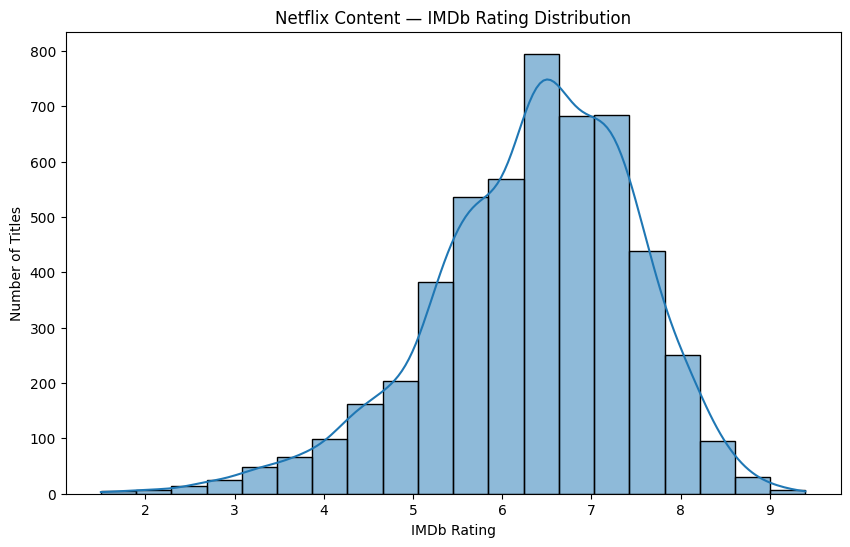

In [276]:
# Visualize IMDb Rating Distribution

plt.figure(figsize=(10, 6))

sns.histplot(
    matched_df["IMDb_Rating"].dropna(),
    bins=20,
    kde=True
)

plt.title("Netflix Content — IMDb Rating Distribution")
plt.xlabel("IMDb Rating")
plt.ylabel("Number of Titles")

plt.show()

In [277]:
# Analyze Matched Titles by Release Year

netflix_yearly = (
    matched_df
    .groupby("OTT_Release_Year")
    .agg(
        Titles=("OTT_Title", "count"),
        Average_Rating=("IMDb_Rating", "mean")
    )
    .reset_index()
)

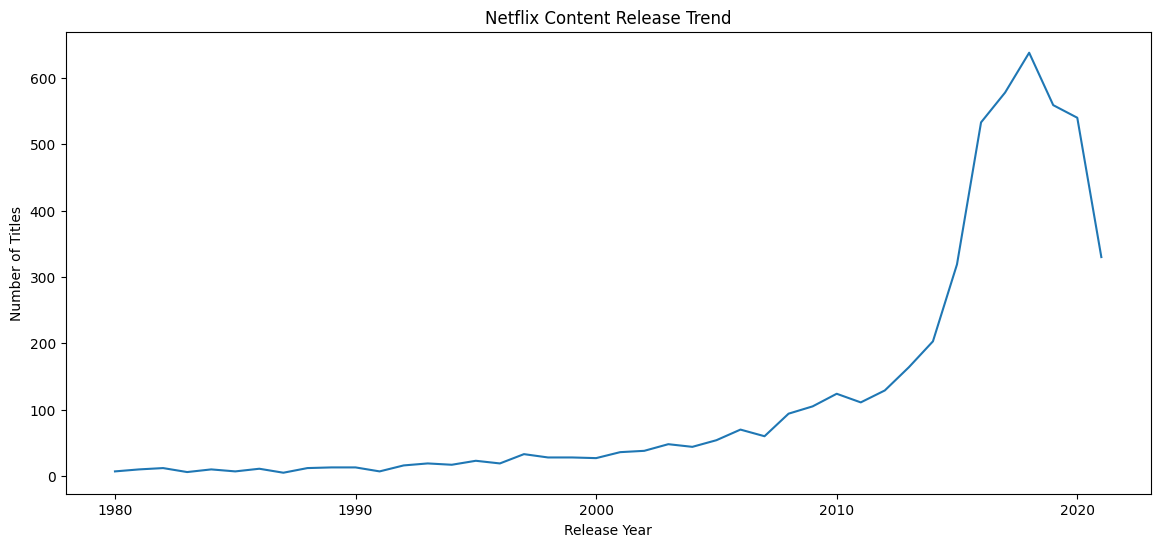

In [278]:
# Visualize Netflix Content Release Trend

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=netflix_yearly,
    x="OTT_Release_Year",
    y="Titles"
)

plt.title("Netflix Content Release Trend")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

In [279]:
# Analyze Top 20 Netflix Titles by IMDb Rating

netflix_top = (
    matched_df[
        matched_df["IMDb_Votes"] >= 10000
    ]
    .sort_values(
        ["IMDb_Rating", "IMDb_Votes"],
        ascending=[False, False]
    )
    .head(20)
)

In [280]:
netflix_top[
    [
        "OTT_Title",
        "OTT_Content_Type",
        "OTT_Release_Year",
        "IMDb_Rating",
        "IMDb_Votes"
    ]
]

,OTT_Title,OTT_Content_Type,OTT_Release_Year,IMDb_Rating,IMDb_Votes
7824,Planet Earth II,TV Show,2016,9.4,176240.0
6412,Blue Planet II,TV Show,2017,9.3,58344.0
3982,Our Planet,TV Show,2019,9.2,63473.0
783,Attack on Titan,TV Show,2013,9.1,736592.0
8483,The Lord of the Rings: The Return of the King,Movie,2003,9.0,2182912.0
8035,Schindler's List,Movie,1993,9.0,1596573.0
684,The Last Dance,TV Show,2020,9.0,182865.0
6882,Frozen Planet,TV Show,2011,9.0,40557.0
3107,Reply 1988,TV Show,2015,9.0,19746.0
2431,My Mister,TV Show,2018,9.0,16010.0


In [281]:
# Visualize Top 20 Netflix Titles by IMDb Rating

netflix_genre = matched_df[
    [
        "OTT_Title",
        "OTT_Genres",
        "IMDb_Rating",
        "IMDb_Votes"
    ]
].dropna(
    subset=["OTT_Genres"]
).copy()

In [282]:
netflix_genre["OTT_Genres"] = (
    netflix_genre["OTT_Genres"]
    .str.split(",")
)

In [283]:
netflix_genre = netflix_genre.explode(
    "OTT_Genres"
)

In [284]:
netflix_genre["OTT_Genres"] = (
    netflix_genre["OTT_Genres"]
    .str.strip()
)

In [285]:
# Analyze Netflix Titles by Genre

netflix_genre_analysis = (
    netflix_genre
    .groupby("OTT_Genres")
    .agg(
        Titles=("OTT_Title", "count"),
        Average_Rating=("IMDb_Rating", "mean"),
        Average_Votes=("IMDb_Votes", "mean")
    )
    .reset_index()
)

In [286]:
netflix_genre_analysis.sort_values(
    "Average_Rating",
    ascending=False
).head(15)

,OTT_Genres,Titles,Average_Rating,Average_Votes
5,Classic & Cult TV,1,8.700000,249347.000000
19,Korean TV Shows,83,7.521687,5889.385542
6,Classic Movies,41,7.436585,291053.341463
27,Science & Nature TV,48,7.381250,8538.895833
11,Docuseries,220,7.247273,7012.322727
2,Anime Series,89,7.213483,28539.741573
25,Romantic TV Shows,185,7.171892,8605.097297
31,Stand-Up Comedy & Talk Shows,18,7.133333,1766.500000
3,British TV Shows,97,7.072165,13038.762887
34,TV Dramas,348,7.071552,21555.080460


In [287]:
# Visualize Netflix Titles by Genre

netflix_genre_reliable = (
    netflix_genre_analysis[
        netflix_genre_analysis["Titles"] >= 30
    ]
    .sort_values(
        "Average_Rating",
        ascending=True
    )
)

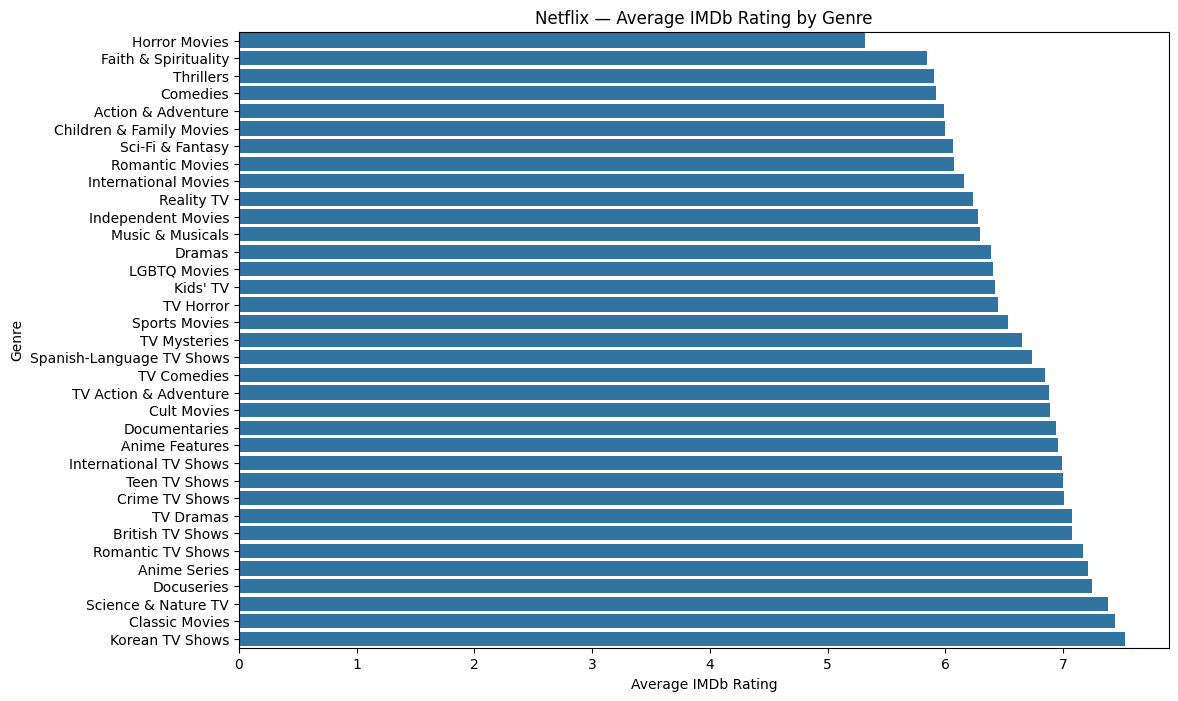

In [288]:
plt.figure(figsize=(12, 8))

sns.barplot(
    data=netflix_genre_reliable,
    x="Average_Rating",
    y="OTT_Genres"
)

plt.title("Netflix — Average IMDb Rating by Genre")
plt.xlabel("Average IMDb Rating")
plt.ylabel("Genre")

plt.show()

In [289]:
# Analyze Matched Titles by Platform

matched_df["Platform"]

0       Netflix
2       Netflix
3       Netflix
5       Netflix
6       Netflix
         ...   
8881    Netflix
8883    Netflix
8885    Netflix
8886    Netflix
8887    Netflix
Name: Platform, Length: 5100, dtype: object

In [290]:
matched_df["Platform"].value_counts()

Platform
Netflix    5100
Name: count, dtype: int64

In [291]:
# Save the matched dataset to a CSV file

output_path = (
    "../data/processed/"
    "netflix_imdb_analysis.csv"
)

matched_df.to_csv(
    output_path,
    index=False
)

print("OTT-IMDb dataset saved!")
print(output_path)

OTT-IMDb dataset saved!
../data/processed/netflix_imdb_analysis.csv


In [292]:
# Save the Netflix genre analysis dataset to a CSV file

netflix_genre_reliable.to_csv(
    "../data/processed/"
    "netflix_genre_analysis.csv",
    index=False
)

## Phase 4B — Multi-Platform Data Integration

In [293]:
import pandas as pd
import numpy as np

netflix = pd.read_csv(
    "../data/ott_raw/netflix_titles.csv"
)

amazon = pd.read_csv(
    "../data/ott_raw/amazon_prime_titles.csv"
)

disney = pd.read_csv(
    "../data/ott_raw/disney_plus_titles.csv"
)

print("Netflix:", netflix.shape)
print("Amazon Prime:", amazon.shape)
print("Disney+:", disney.shape)

Netflix: (8807, 12)
Amazon Prime: (9668, 12)
Disney+: (1450, 12)


In [294]:
# Check column names

print("Netflix columns:")
print(netflix.columns.tolist())

print("\nAmazon Prime columns:")
print(amazon.columns.tolist())

print("\nDisney+ columns:")
print(disney.columns.tolist())

Netflix columns:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

Amazon Prime columns:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

Disney+ columns:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


In [295]:
netflix_std = netflix.copy()

netflix_std.rename(
    columns={
        "show_id": "OTT_ID",
        "title": "Title",
        "type": "OTT_Content_Type",
        "release_year": "Release_Year",
        "rating": "Age_Rating",
        "listed_in": "Genres",
        "country": "Country",
        "description": "Description"
    },
    inplace=True
)

netflix_std["Platform"] = "Netflix"

In [296]:
amazon_std = amazon.copy()

amazon_std.rename(
    columns={
        "show_id": "OTT_ID",
        "title": "Title",
        "type": "OTT_Content_Type",
        "release_year": "Release_Year",
        "rating": "Age_Rating",
        "listed_in": "Genres",
        "country": "Country",
        "description": "Description"
    },
    inplace=True
)

amazon_std["Platform"] = "Amazon Prime Video"

In [297]:
disney_std = disney.copy()

disney_std.rename(
    columns={
        "show_id": "OTT_ID",
        "title": "Title",
        "type": "OTT_Content_Type",
        "release_year": "Release_Year",
        "rating": "Age_Rating",
        "listed_in": "Genres",
        "country": "Country",
        "description": "Description"
    },
    inplace=True
)

disney_std["Platform"] = "Disney+"

In [298]:
# Standardize columns across all OTT datasets

common_columns = [
    "Platform",
    "OTT_ID",
    "Title",
    "OTT_Content_Type",
    "Release_Year",
    "Age_Rating",
    "Genres",
    "Country",
    "Description"
]

netflix_std = netflix_std[
    [col for col in common_columns if col in netflix_std.columns]
]

amazon_std = amazon_std[
    [col for col in common_columns if col in amazon_std.columns]
]

disney_std = disney_std[
    [col for col in common_columns if col in disney_std.columns]
]

In [299]:
# Ensure all datasets have the same columns, adding missing columns with NaN values

for data in [
    netflix_std,
    amazon_std,
    disney_std
]:
    for col in common_columns:
        if col not in data.columns:
            data[col] = np.nan

In [300]:
netflix_std = netflix_std[common_columns]
amazon_std = amazon_std[common_columns]
disney_std = disney_std[common_columns]

In [301]:
# Combine all OTT datasets into a single master dataset

ott_master = pd.concat(
    [
        netflix_std,
        amazon_std,
        disney_std
    ],
    ignore_index=True
)

In [302]:
print("Combined OTT dataset:", ott_master.shape)

Combined OTT dataset: (19925, 9)


In [303]:
ott_master["Platform"].value_counts()

Platform
Amazon Prime Video    9668
Netflix               8807
Disney+               1450
Name: count, dtype: int64

In [304]:
# Check for duplicate titles in the combined OTT dataset

ott_master["Title"].duplicated().sum()

np.int64(447)

In [305]:
# Analyze Platform Availability for Each Title

platform_availability = (
    ott_master
    .groupby("Title")["Platform"]
    .agg(
        lambda x: ", ".join(
            sorted(set(x))
        )
    )
    .reset_index()
)

In [306]:
platform_availability.head(20)

,Title,Platform
0,"""Mixed Up""",Amazon Prime Video
1,"""The Paramedic Angel""",Amazon Prime Video
2,#Alive,Netflix
3,#AnneFrank - Parallel Stories,Netflix
4,#FriendButMarried,Netflix
5,#FriendButMarried 2,Netflix
6,#Home,Amazon Prime Video
7,#Home (4K UHD),Amazon Prime Video
8,#IGotThis,Amazon Prime Video
9,#IMomSoHard Live,Amazon Prime Video


In [307]:
# Count the number of platforms available for each title

platform_count = (
    ott_master
    .groupby("Title")["Platform"]
    .nunique()
    .reset_index(
        name="Platform_Count"
    )
)

platform_count["Platform_Count"].value_counts()

Platform_Count
1    19032
2      445
3        1
Name: count, dtype: int64

In [308]:
# Identify titles available on multiple platforms

multi_platform_titles = platform_count[
    platform_count["Platform_Count"] >= 2
]

multi_platform_titles.head(20)

,Title,Platform_Count
41,10 Things I Hate About You,2
73,12 Dates of Christmas,2
212,21,2
229,24 Hours to Live,2
326,6 Days,2
332,60 Days In,2
448,A Family Man,2
549,A Night at the Roxbury,2
588,A Second Chance,2
665,A Wrinkle in Time,2


In [309]:
# Create a Platform Matrix

platform_matrix = pd.crosstab(
    ott_master["Title"],
    ott_master["Platform"]
)

In [310]:
platform_matrix.head()

Platform,Amazon Prime Video,Disney+,Netflix
Title,,,
"""Mixed Up""",1,0,0
"""The Paramedic Angel""",1,0,0
#Alive,0,0,1
#AnneFrank - Parallel Stories,0,0,1
#FriendButMarried,0,0,1


In [311]:
# Load IMDB movie ratings data

imdb = pd.read_csv(
    "../data/processed/imdb_movies_ratings_advanced.csv"
)

In [312]:
# Check the shape of the IMDb dataset

imdb["Title_Key"] = (
    imdb["Title"]
    .astype(str)
    .str.lower()
    .str.replace(
        r"[^\w\s]",
        "",
        regex=True
    )
    .str.replace(
        r"\s+",
        " ",
        regex=True
    )
    .str.strip()
)

In [313]:
# Create a Title Key for Matching

ott_master["Title_Key"] = (
    ott_master["Title"]
    .astype(str)
    .str.lower()
    .str.replace(
        r"[^\w\s]",
        "",
        regex=True
    )
    .str.replace(
        r"\s+",
        " ",
        regex=True
    )
    .str.strip()
)

In [314]:
# Convert Release Year to Numeric for Consistency

imdb["Release_Year"] = pd.to_numeric(
    imdb["Release_Year"],
    errors="coerce"
)

ott_master["Release_Year"] = pd.to_numeric(
    ott_master["Release_Year"],
    errors="coerce"
)

In [315]:
# Create a Match Key for Merging

imdb["Match_Key"] = (
    imdb["Title_Key"]
    + "_"
    + imdb["Release_Year"]
      .fillna(0)
      .astype(int)
      .astype(str)
)

In [316]:
ott_master["Match_Key"] = (
    ott_master["Title_Key"]
    + "_"
    + ott_master["Release_Year"]
      .fillna(0)
      .astype(int)
      .astype(str)
)

Merge OTT + IMDb

In [317]:
ott_imdb_master = ott_master.merge(
    imdb[
        [
            "Title_ID",
            "Match_Key",
            "IMDb_Rating",
            "IMDb_Votes",
            "Content_Type",
            "Genres"
        ]
    ],
    on="Match_Key",
    how="left",
    suffixes=("_OTT", "_IMDb")
)

In [318]:
print(
    "OTT + IMDb Shape:",
    ott_imdb_master.shape
)

OTT + IMDb Shape: (20063, 16)


In [319]:
# Calculate Match Rate

matched = (
    ott_imdb_master["Title_ID"]
    .notna()
    .sum()
)

total = len(ott_imdb_master)

match_rate = matched / total * 100

print("Total OTT Records:", total)
print("Matched IMDb Records:", matched)
print(f"Match Rate: {match_rate:.2f}%")

Total OTT Records: 20063
Matched IMDb Records: 8539
Match Rate: 42.56%


In [320]:
ott_imdb_master.columns.tolist()

['Platform',
 'OTT_ID',
 'Title',
 'OTT_Content_Type',
 'Release_Year',
 'Age_Rating',
 'Genres_OTT',
 'Country',
 'Description',
 'Title_Key',
 'Match_Key',
 'Title_ID',
 'IMDb_Rating',
 'IMDb_Votes',
 'Content_Type',
 'Genres_IMDb']

In [321]:
# Analyze Matched Titles

matched_titles = ott_imdb_master[
    ott_imdb_master["Title_ID"].notna()
].copy()

matched_titles[
    [
        "Title",
        "Release_Year",
        "Title_ID",
        "IMDb_Rating",
        "IMDb_Votes"
    ]
].head(30)

,Title,Release_Year,Title_ID,IMDb_Rating,IMDb_Votes
0,Dick Johnson Is Dead,2020,tt11394180,7.4,7694.0
2,Ganglands,2021,tt13278100,7.2,5150.0
3,Jailbirds New Orleans,2021,tt15320436,6.5,358.0
5,Midnight Mass,2021,tt10574558,7.7,172210.0
6,My Little Pony: A New Generation,2021,tt10101702,6.8,5178.0
7,Sankofa,1993,tt0108041,7.0,905.0
9,The Starling,2021,tt5164438,6.4,17395.0
10,"Vendetta: Truth, Lies and The Mafia",2021,tt14216574,6.7,387.0
11,Bangkok Breaking,2021,tt14202282,5.9,476.0
12,Je Suis Karl,2021,tt9205538,5.6,1740.0


In [322]:
ott_imdb_analysis = (
    ott_imdb_master[
        ott_imdb_master["Title_ID"].notna()
    ]
    .copy()
)

In [323]:
print(
    "Matched analysis records:",
    len(ott_imdb_analysis)
)

Matched analysis records: 8539


In [324]:
platform_counts = (
    ott_imdb_analysis["Platform"]
    .value_counts()
)

platform_counts

Platform
Netflix               5240
Amazon Prime Video    2787
Disney+                512
Name: count, dtype: int64

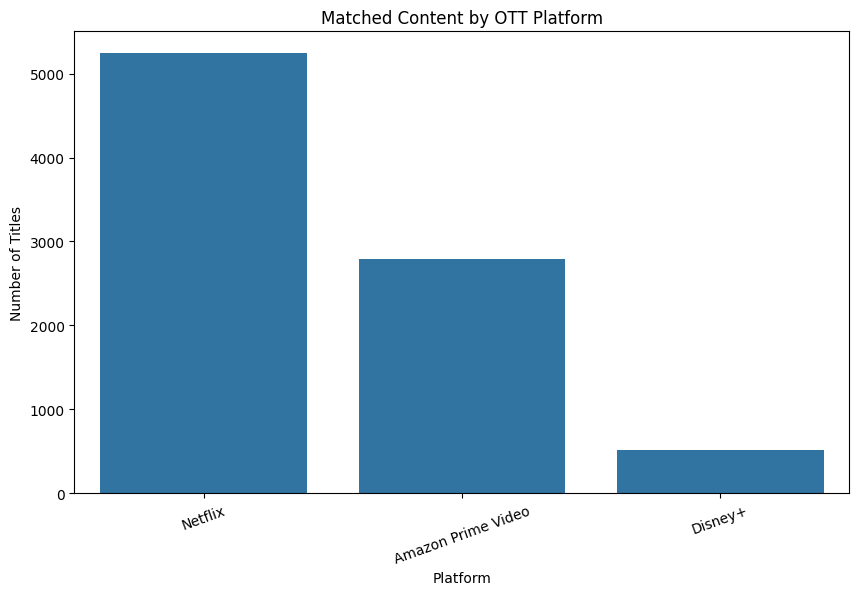

In [325]:
# Visualize Matched Content by OTT Platform

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.barplot(
    x=platform_counts.index,
    y=platform_counts.values
)

plt.title("Matched Content by OTT Platform")
plt.xlabel("Platform")
plt.ylabel("Number of Titles")

plt.xticks(rotation=20)

plt.show()

In [326]:
# Analyze Matched Titles by Platform

platform_summary = (
    ott_imdb_analysis
    .groupby("Platform")
    .agg(
        Titles=("Title", "count"),
        Average_Rating=("IMDb_Rating", "mean"),
        Median_Rating=("IMDb_Rating", "median"),
        Average_Votes=("IMDb_Votes", "mean"),
        Total_Votes=("IMDb_Votes", "sum")
    )
    .reset_index()
)

In [327]:
platform_summary

,Platform,Titles,Average_Rating,Median_Rating,Average_Votes,Total_Votes
0,Amazon Prime Video,2787,5.875996,6.0,16261.855041,45321790.0
1,Disney+,512,6.653320,6.7,118574.054688,60709916.0
2,Netflix,5240,6.355458,6.5,42057.941031,220383611.0


In [328]:
# Round the numerical values for better readability

platform_summary[
    [
        "Average_Rating",
        "Median_Rating",
        "Average_Votes"
    ]
] = platform_summary[
    [
        "Average_Rating",
        "Median_Rating",
        "Average_Votes"
    ]
].round(2)

platform_summary

,Platform,Titles,Average_Rating,Median_Rating,Average_Votes,Total_Votes
0,Amazon Prime Video,2787,5.88,6.0,16261.86,45321790.0
1,Disney+,512,6.65,6.7,118574.05,60709916.0
2,Netflix,5240,6.36,6.5,42057.94,220383611.0


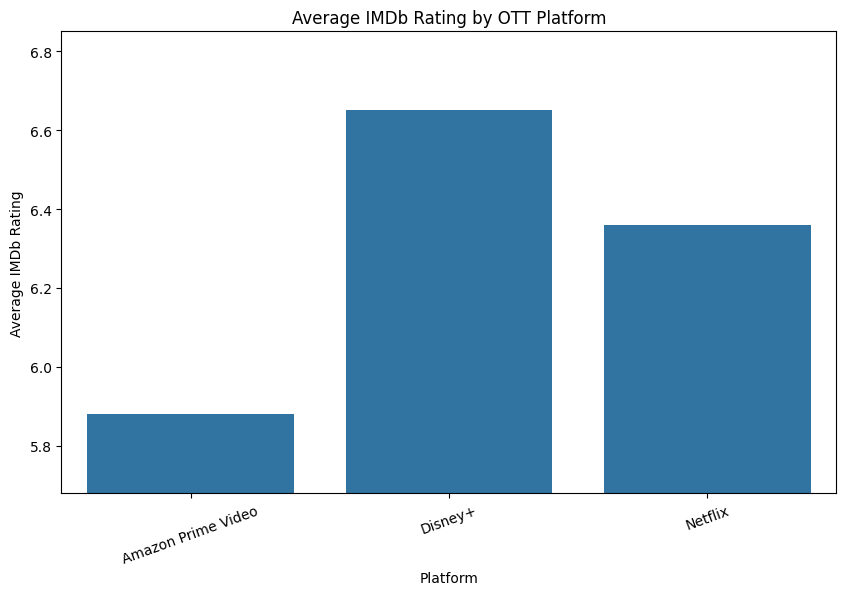

In [329]:
# Visualize Average IMDb Rating by OTT Platform

plt.figure(figsize=(10, 6))

sns.barplot(
    data=platform_summary,
    x="Platform",
    y="Average_Rating"
)

plt.title(
    "Average IMDb Rating by OTT Platform"
)

plt.xlabel("Platform")
plt.ylabel("Average IMDb Rating")

plt.xticks(rotation=20)

plt.ylim(
    platform_summary["Average_Rating"].min() - 0.2,
    platform_summary["Average_Rating"].max() + 0.2
)

plt.show()

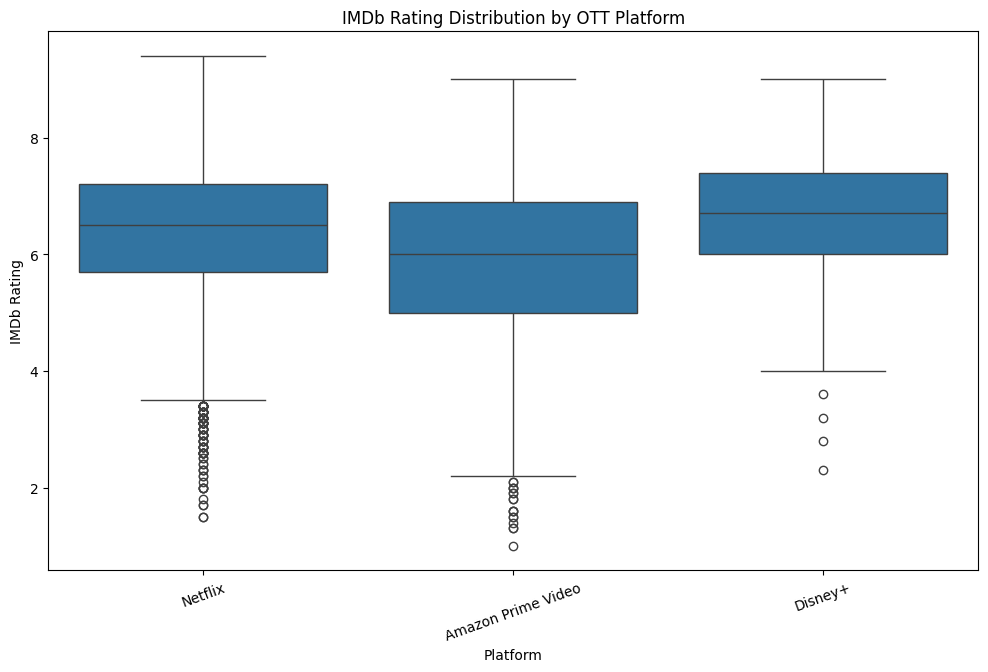

In [330]:
# Visualize IMDb Rating Distribution by OTT Platform

plt.figure(figsize=(12, 7))

sns.boxplot(
    data=ott_imdb_analysis,
    x="Platform",
    y="IMDb_Rating"
)

plt.title(
    "IMDb Rating Distribution by OTT Platform"
)

plt.xlabel("Platform")
plt.ylabel("IMDb Rating")

plt.xticks(rotation=20)

plt.show()

In [331]:
# Visualize OTT Content Type Distribution by Platform

platform_content_type = pd.crosstab(
    ott_imdb_analysis["Platform"],
    ott_imdb_analysis["OTT_Content_Type"]
)

platform_content_type

OTT_Content_Type,Movie,TV Show
Platform,,
Amazon Prime Video,2355,432
Disney+,347,165
Netflix,4028,1212


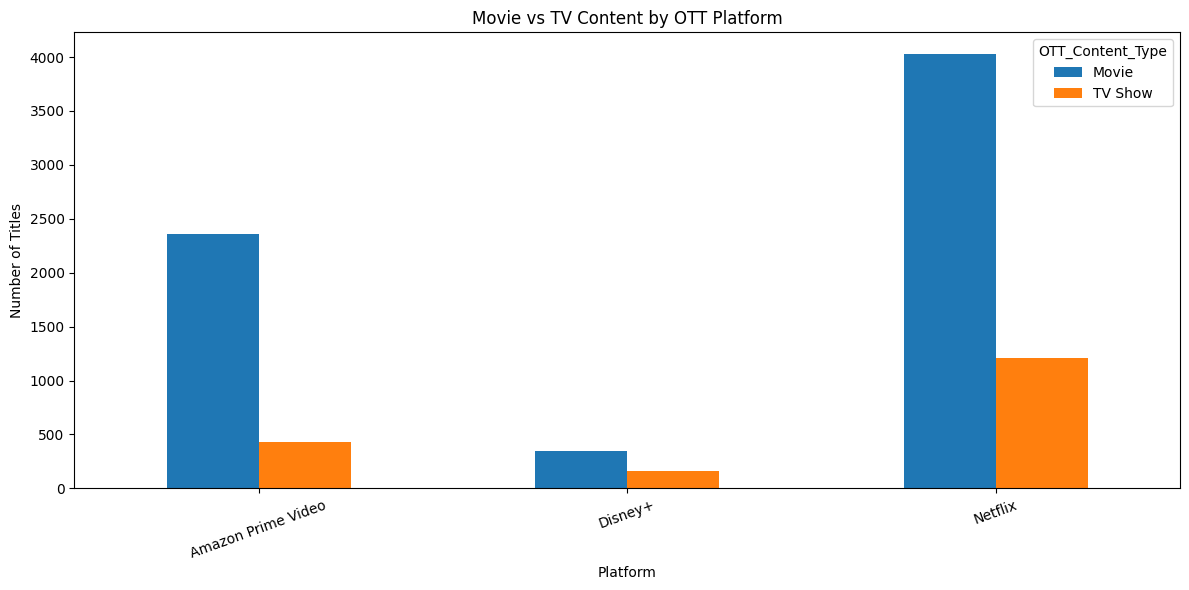

In [332]:
# Visualize OTT Content Type Distribution by Platform

platform_content_type.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Movie vs TV Content by OTT Platform"
)

plt.xlabel("Platform")
plt.ylabel("Number of Titles")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

In [333]:
# Visualize Platform Share

platform_share = (
    ott_imdb_analysis["Platform"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

platform_share

Platform
Netflix               61.37
Amazon Prime Video    32.64
Disney+                6.00
Name: proportion, dtype: float64

In [334]:
# Visualize Platform Share

platform_year = (
    ott_imdb_analysis
    .groupby(
        [
            "Release_Year",
            "Platform"
        ]
    )
    .size()
    .reset_index(
        name="Title_Count"
    )
)

platform_year.head()

,Release_Year,Platform,Title_Count
0,1980,Amazon Prime Video,13
1,1980,Disney+,1
2,1980,Netflix,7
3,1981,Amazon Prime Video,13
4,1981,Disney+,3


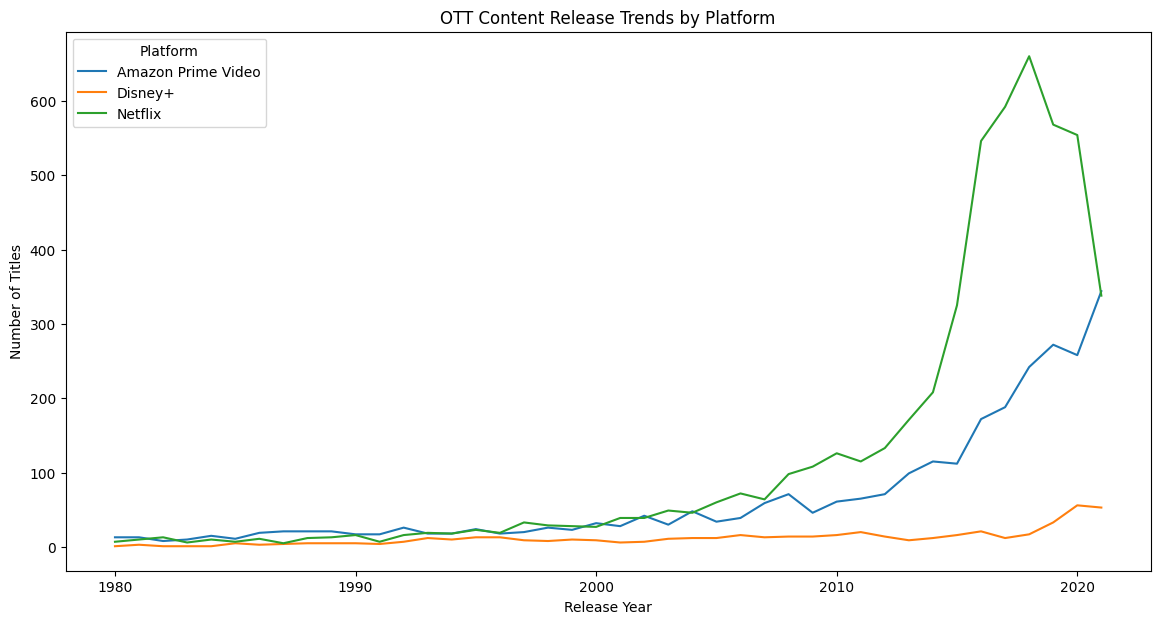

In [335]:
# Visualize OTT Content Release Trends by Platform

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=platform_year,
    x="Release_Year",
    y="Title_Count",
    hue="Platform"
)

plt.title(
    "OTT Content Release Trends by Platform"
)

plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

In [336]:
# Analyze Matched Titles by Genre

platform_genre = ott_imdb_analysis[
    [
        "Platform",
        "Title",
        "Genres_OTT",
        "IMDb_Rating",
        "IMDb_Votes"
    ]
].dropna(
    subset=["Genres_OTT"]
).copy()

In [337]:
platform_genre["Genres_OTT"] = (
    platform_genre["Genres_OTT"]
    .astype(str)
    .str.split(",")
)

In [338]:
platform_genre = platform_genre.explode(
    "Genres_OTT"
)

In [339]:
platform_genre["Genres_OTT"] = (
    platform_genre["Genres_OTT"]
    .str.strip()
)

In [340]:
platform_genre.head()

,Platform,Title,Genres_OTT,IMDb_Rating,IMDb_Votes
0,Netflix,Dick Johnson Is Dead,Documentaries,7.4,7694.0
2,Netflix,Ganglands,Crime TV Shows,7.2,5150.0
2,Netflix,Ganglands,International TV Shows,7.2,5150.0
2,Netflix,Ganglands,TV Action & Adventure,7.2,5150.0
3,Netflix,Jailbirds New Orleans,Docuseries,6.5,358.0


In [341]:
# Analyze Matched Titles by Genre and Platform

platform_genre_counts = (
    platform_genre
    .groupby(
        [
            "Platform",
            "Genres_OTT"
        ]
    )
    .size()
    .reset_index(
        name="Title_Count"
    )
)

In [342]:
platform_genre_counts.sort_values(
    "Title_Count",
    ascending=False
).head(30)

,Platform,Genres_OTT,Title_Count
86,Netflix,International Movies,1883
82,Netflix,Dramas,1825
8,Amazon Prime Video,Drama,1254
77,Netflix,Comedies,1194
87,Netflix,International TV Shows,708
70,Netflix,Action & Adventure,697
6,Amazon Prime Video,Comedy,695
85,Netflix,Independent Movies,603
23,Amazon Prime Video,Suspense,600
0,Amazon Prime Video,Action,586


In [343]:
# Platform × Genre Heatmap

genre_platform_matrix = pd.pivot_table(
    platform_genre_counts,
    index="Genres_OTT",
    columns="Platform",
    values="Title_Count",
    fill_value=0
)

In [344]:
# Visualize Platform × Genre Heatmap

top_genres = (
    genre_platform_matrix
    .sum(axis=1)
    .sort_values(
        ascending=False
    )
    .head(15)
    .index
)

genre_platform_matrix = (
    genre_platform_matrix
    .loc[top_genres]
)

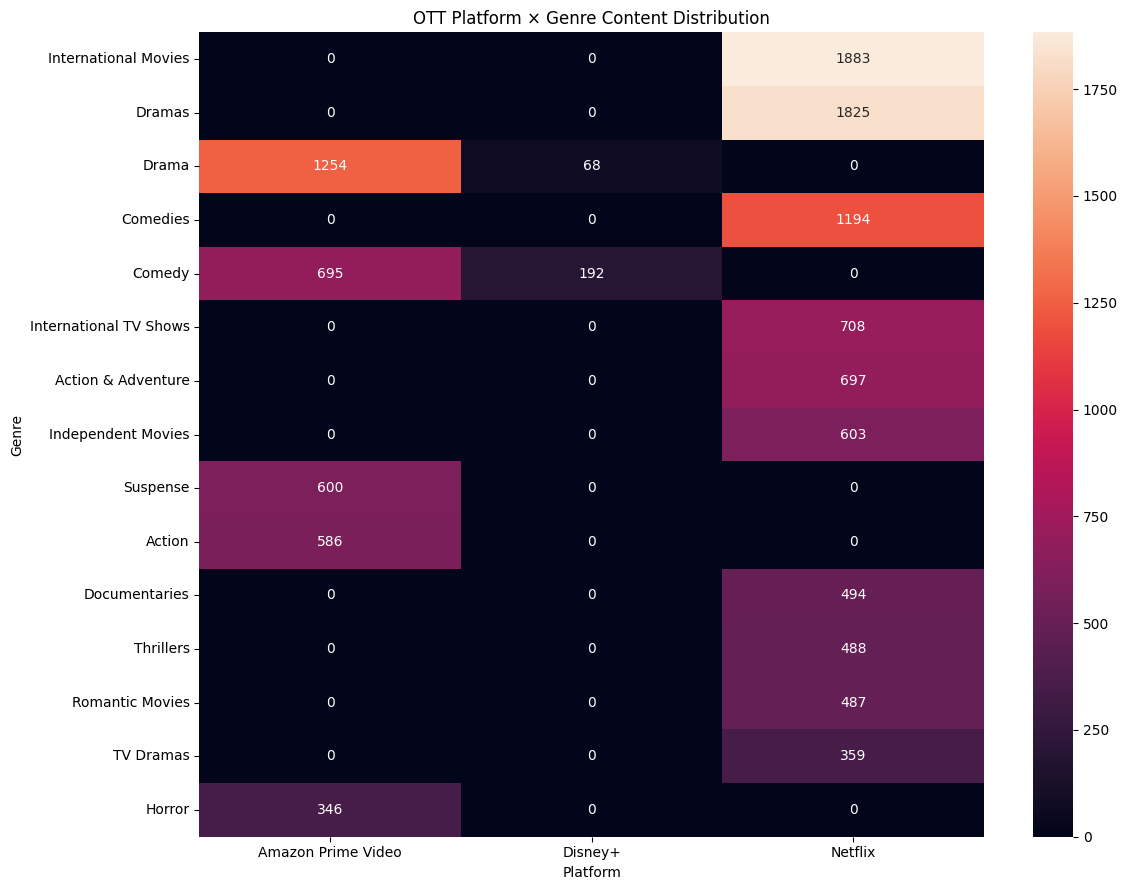

In [345]:
# Visualize Platform × Genre Heatmap

plt.figure(figsize=(12, 9))

sns.heatmap(
    genre_platform_matrix,
    annot=True,
    fmt=".0f"
)

plt.title(
    "OTT Platform × Genre Content Distribution"
)

plt.xlabel("Platform")
plt.ylabel("Genre")

plt.tight_layout()

plt.show()

In [346]:
# Analyze Average IMDb Rating by Genre and Platform

platform_genre_rating = (
    platform_genre
    .groupby(
        [
            "Platform",
            "Genres_OTT"
        ]
    )
    .agg(
        Titles=("Title", "count"),
        Average_Rating=("IMDb_Rating", "mean"),
        Average_Votes=("IMDb_Votes", "mean")
    )
    .reset_index()
)

In [347]:
platform_genre_rating.sort_values(
    "Average_Rating",
    ascending=False
).head(30)

,Platform,Genres_OTT,Titles,Average_Rating,Average_Votes
75,Netflix,Classic & Cult TV,1,8.700000,249347.000000
65,Disney+,Survival,4,7.650000,803.000000
44,Disney+,Docuseries,57,7.500000,1759.561404
89,Netflix,Korean TV Shows,86,7.498837,5710.511628
64,Disney+,Superhero,3,7.466667,504018.000000
76,Netflix,Classic Movies,42,7.438095,284705.857143
68,Disney+,Travel,2,7.400000,178.000000
55,Disney+,Mystery,6,7.383333,189655.666667
97,Netflix,Science & Nature TV,50,7.374000,8214.700000
35,Disney+,Biographical,23,7.300000,65472.304348


In [348]:
# Remove Very Small Groups

platform_genre_reliable = (
    platform_genre_rating[
        platform_genre_rating["Titles"] >= 20
    ]
    .copy()
)

In [349]:
platform_genre_reliable.sort_values(
    "Average_Rating",
    ascending=False
).head(30)

,Platform,Genres_OTT,Titles,Average_Rating,Average_Votes
44,Disney+,Docuseries,57,7.500000,1759.561404
89,Netflix,Korean TV Shows,86,7.498837,5710.511628
76,Netflix,Classic Movies,42,7.438095,284705.857143
97,Netflix,Science & Nature TV,50,7.374000,8214.700000
35,Disney+,Biographical,23,7.300000,65472.304348
49,Disney+,Historical,20,7.255000,36189.100000
81,Netflix,Docuseries,226,7.248230,6886.597345
72,Netflix,Anime Series,93,7.210753,28001.268817
95,Netflix,Romantic TV Shows,191,7.150262,8420.565445
73,Netflix,British TV Shows,100,7.093000,12658.040000


In [350]:
# Top-Rated Content by Platform

top_by_platform = (
    ott_imdb_analysis[
        ott_imdb_analysis["IMDb_Votes"] >= 10000
    ]
    .sort_values(
        [
            "Platform",
            "IMDb_Rating",
            "IMDb_Votes"
        ],
        ascending=[
            True,
            False,
            False
        ]
    )
    .groupby("Platform")
    .head(10)
)

In [351]:
top_by_platform[
    [
        "Platform",
        "Title",
        "Release_Year",
        "IMDb_Rating",
        "IMDb_Votes"
    ]
]

,Platform,Title,Release_Year,IMDb_Rating,IMDb_Votes
10292,Amazon Prime Video,Panchayat,2020,9.0,119009.0
14376,Amazon Prime Video,Clarkson's Farm,2021,9.0,89413.0
9077,Amazon Prime Video,VINLAND SAGA,2019,8.9,146854.0
10995,Amazon Prime Video,Invincible,2021,8.7,349457.0
9786,Amazon Prime Video,Stop Making Sense,1984,8.7,24394.0
16484,Amazon Prime Video,#Home,2021,8.7,19982.0
9301,Amazon Prime Video,The Untamed,2019,8.7,16350.0
12066,Amazon Prime Video,Bandish Bandits,2020,8.6,20665.0
11601,Amazon Prime Video,Dear Zachary: A Letter To A Son About His Father,2008,8.5,46244.0
10131,Amazon Prime Video,Queer as Folk,2000,8.5,24193.0


In [352]:
# Platform Popularity

ott_imdb_analysis["Log_Votes"] = np.log10(
    ott_imdb_analysis["IMDb_Votes"] + 1
)

In [353]:
platform_popularity = (
    ott_imdb_analysis
    .groupby("Platform")
    .agg(
        Average_Log_Votes=("Log_Votes", "mean"),
        Total_Votes=("IMDb_Votes", "sum")
    )
    .reset_index()
)

platform_popularity

,Platform,Average_Log_Votes,Total_Votes
0,Amazon Prime Video,3.278312,45321790.0
1,Disney+,4.175685,60709916.0
2,Netflix,3.669911,220383611.0


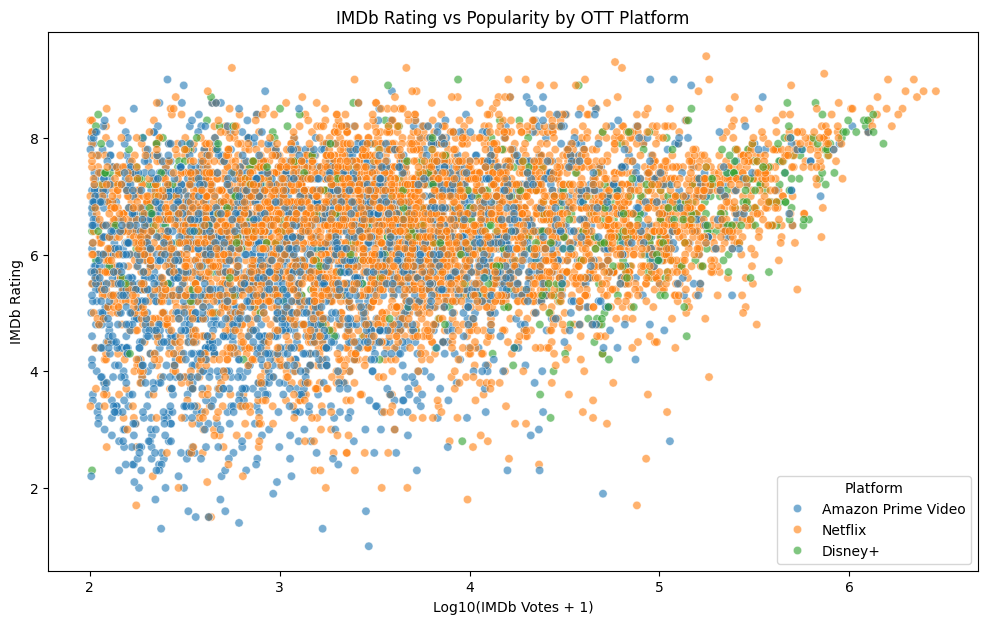

In [354]:
# Rating vs Popularity

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=ott_imdb_analysis.sample(
        min(10000, len(ott_imdb_analysis)),
        random_state=42
    ),
    x="Log_Votes",
    y="IMDb_Rating",
    hue="Platform",
    alpha=0.6
)

plt.title(
    "IMDb Rating vs Popularity by OTT Platform"
)

plt.xlabel(
    "Log10(IMDb Votes + 1)"
)

plt.ylabel("IMDb Rating")

plt.show()

In [355]:
# Calculate Platform Correlation

platform_correlations = (
    ott_imdb_analysis
    .groupby("Platform")
    .apply(
        lambda x: x[
            ["IMDb_Rating", "Log_Votes"]
        ].corr().iloc[0, 1]
    )
    .reset_index(
        name="Rating_Popularity_Correlation"
    )
)

C:\Users\K DIVYASH\AppData\Local\Temp\ipykernel_73608\1134137130.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


In [356]:
platform_correlations

,Platform,Rating_Popularity_Correlation
0,Amazon Prime Video,0.262743
1,Disney+,0.095999
2,Netflix,0.218769


In [357]:
# Content Success Score

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

ott_imdb_analysis[
    "Popularity_Score"
] = scaler.fit_transform(
    ott_imdb_analysis[
        ["Log_Votes"]
    ]
)

In [358]:
ott_imdb_analysis[
    "Rating_Score"
] = (
    ott_imdb_analysis["IMDb_Rating"] / 10
)

In [359]:
ott_imdb_analysis[
    "Content_Success_Score"
] = (
    0.70 *
    ott_imdb_analysis["Rating_Score"]
    +
    0.30 *
    ott_imdb_analysis["Popularity_Score"]
) * 100

In [360]:
# Platform Success Summary

platform_success = (
    ott_imdb_analysis
    .groupby("Platform")
    .agg(
        Average_Success_Score=(
            "Content_Success_Score",
            "mean"
        ),
        Highest_Success_Score=(
            "Content_Success_Score",
            "max"
        )
    )
    .reset_index()
)

In [361]:
platform_success

,Platform,Average_Success_Score,Highest_Success_Score
0,Amazon Prime Video,49.719203,84.754850
1,Disney+,61.209147,86.578317
2,Netflix,55.714986,92.217809


In [362]:
# Multi-Platform Availability

platform_availability = (
    ott_master
    .groupby("Title")["Platform"]
    .agg(
        lambda x: ", ".join(
            sorted(set(x))
        )
    )
    .reset_index()
)

In [363]:
platform_count = (
    ott_master
    .groupby("Title")["Platform"]
    .nunique()
    .reset_index(
        name="Platform_Count"
    )
)

In [364]:
platform_availability = platform_availability.merge(
    platform_count,
    on="Title"
)

In [365]:
platform_availability.head(20)

,Title,Platform,Platform_Count
0,"""Mixed Up""",Amazon Prime Video,1
1,"""The Paramedic Angel""",Amazon Prime Video,1
2,#Alive,Netflix,1
3,#AnneFrank - Parallel Stories,Netflix,1
4,#FriendButMarried,Netflix,1
5,#FriendButMarried 2,Netflix,1
6,#Home,Amazon Prime Video,1
7,#Home (4K UHD),Amazon Prime Video,1
8,#IGotThis,Amazon Prime Video,1
9,#IMomSoHard Live,Amazon Prime Video,1


In [366]:
# Multi-Platform Titles

multi_platform_titles = (
    platform_availability[
        platform_availability["Platform_Count"] >= 2
    ]
    .sort_values(
        "Platform_Count",
        ascending=False
    )
)

multi_platform_titles.head(30)

,Title,Platform,Platform_Count
15017,Tarzan,"Amazon Prime Video, Disney+, Netflix",3
332,60 Days In,"Amazon Prime Video, Netflix",2
448,A Family Man,"Amazon Prime Video, Netflix",2
549,A Night at the Roxbury,"Amazon Prime Video, Netflix",2
588,A Second Chance,"Amazon Prime Video, Netflix",2
665,A Wrinkle in Time,"Disney+, Netflix",2
705,APEX: The Story of the Hypercar,"Amazon Prime Video, Netflix",2
755,Abhinetri,"Amazon Prime Video, Netflix",2
780,Accident,"Amazon Prime Video, Netflix",2
791,Across The Line,"Amazon Prime Video, Netflix",2


# Save Everything

In [367]:
platform_summary.to_csv(
    "../data/processed/platform_summary.csv",
    index=False
)

In [368]:
platform_genre_counts.to_csv(
    "../data/processed/platform_genre_analysis.csv",
    index=False
)

In [369]:
platform_genre_reliable.to_csv(
    "../data/processed/platform_genre_rating.csv",
    index=False
)

In [370]:
platform_success.to_csv(
    "../data/processed/platform_success_summary.csv",
    index=False
)

In [371]:
platform_correlations.to_csv(
    "../data/processed/platform_rating_correlation.csv",
    index=False
)

In [372]:
multi_platform_titles.to_csv(
    "../data/processed/multi_platform_titles.csv",
    index=False
)

In [373]:
ott_imdb_analysis.to_csv(
    "../data/processed/ott_imdb_analysis.csv",
    index=False
)

In [374]:
print(platform_summary)

             Platform  Titles  Average_Rating  Median_Rating  Average_Votes  \
0  Amazon Prime Video    2787            5.88            6.0       16261.86   
1             Disney+     512            6.65            6.7      118574.05   
2             Netflix    5240            6.36            6.5       42057.94   

   Total_Votes  
0   45321790.0  
1   60709916.0  
2  220383611.0  


In [375]:
print(platform_success)

             Platform  Average_Success_Score  Highest_Success_Score
0  Amazon Prime Video              49.719203              84.754850
1             Disney+              61.209147              86.578317
2             Netflix              55.714986              92.217809


In [376]:
print(
    f"Multi-platform titles: "
    f"{len(multi_platform_titles)}"
)

Multi-platform titles: 446


Platform Rating Ranking

In [377]:
platform_ranking = (
    platform_summary
    .sort_values(
        "Average_Rating",
        ascending=False
    )
    .reset_index(drop=True)
)

platform_ranking[
    [
        "Platform",
        "Titles",
        "Average_Rating",
        "Median_Rating"
    ]
]

,Platform,Titles,Average_Rating,Median_Rating
0,Disney+,512,6.65,6.7
1,Netflix,5240,6.36,6.5
2,Amazon Prime Video,2787,5.88,6.0


In [378]:
# Multi-Platform Distribution

platform_count_distribution = (
    platform_availability[
        "Platform_Count"
    ]
    .value_counts()
    .sort_index()
)

platform_count_distribution

Platform_Count
1    19032
2      445
3        1
Name: count, dtype: int64

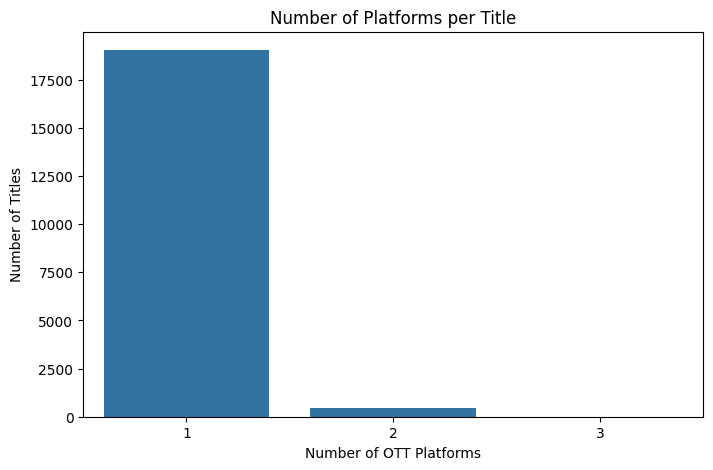

In [379]:
# Visualize Multi-Platform Distribution

plt.figure(figsize=(8, 5))

sns.barplot(
    x=platform_count_distribution.index,
    y=platform_count_distribution.values
)

plt.title(
    "Number of Platforms per Title"
)

plt.xlabel("Number of OTT Platforms")
plt.ylabel("Number of Titles")

plt.show()

In [380]:
# Find the 446 Multi-Platform Titles

multi_platform_detail = (
    multi_platform_titles
    .merge(
        ott_imdb_analysis[
            [
                "Title",
                "IMDb_Rating",
                "IMDb_Votes"
            ]
        ].drop_duplicates("Title"),
        on="Title",
        how="left"
    )
)

In [381]:
multi_platform_detail.sort_values(
    "IMDb_Rating",
    ascending=False
).head(30)

,Title,Platform,Platform_Count,IMDb_Rating,IMDb_Votes
382,The Hunt,"Amazon Prime Video, Netflix",2,9.2,4648.0
259,One,"Amazon Prime Video, Netflix",2,9.2,560.0
261,One Strange Rock,"Disney+, Netflix",2,8.7,8670.0
406,The Untamed,"Amazon Prime Video, Netflix",2,8.7,16350.0
417,WWII in HD,"Amazon Prime Video, Netflix",2,8.6,2599.0
115,Eh Janam Tumhare Lekhe,"Amazon Prime Video, Netflix",2,8.6,441.0
425,Word of Honor,"Amazon Prime Video, Netflix",2,8.3,5184.0
60,Brain Games,"Disney+, Netflix",2,8.2,3752.0
49,"Big Dreams, Small Spaces","Amazon Prime Video, Netflix",2,8.2,386.0
44,Before the Flood,"Disney+, Netflix",2,8.2,29729.0


## SQL Analytics Preparation

In [382]:
final_sql_df = pd.read_csv(
    "../data/processed/ott_imdb_analysis.csv"
)

print("Rows:", len(final_sql_df))
print("Columns:", len(final_sql_df.columns))

Rows: 8539
Columns: 20


In [383]:
final_sql_df.columns.tolist()

['Platform',
 'OTT_ID',
 'Title',
 'OTT_Content_Type',
 'Release_Year',
 'Age_Rating',
 'Genres_OTT',
 'Country',
 'Description',
 'Title_Key',
 'Match_Key',
 'Title_ID',
 'IMDb_Rating',
 'IMDb_Votes',
 'Content_Type',
 'Genres_IMDb',
 'Log_Votes',
 'Popularity_Score',
 'Rating_Score',
 'Content_Success_Score']

In [384]:
sql_df = final_sql_df[
    [
        "Platform",
        "Title",
        "OTT_Content_Type",
        "Release_Year",
        "Age_Rating",
        "Genres_OTT",
        "Country",
        "IMDb_Rating",
        "IMDb_Votes",
        "Content_Success_Score"
    ]
].copy()

In [385]:
sql_df.head()

,Platform,Title,OTT_Content_Type,Release_Year,Age_Rating,Genres_OTT,Country,IMDb_Rating,IMDb_Votes,Content_Success_Score
0,Netflix,Dick Johnson Is Dead,Movie,2020,PG-13,Documentaries,United States,7.4,7694.0,64.484714
1,Netflix,Ganglands,TV Show,2021,TV-MA,"Crime TV Shows, International TV Shows, TV Act...",NaN,7.2,5150.0,61.909744
2,Netflix,Jailbirds New Orleans,TV Show,2021,TV-MA,"Docuseries, Reality TV",NaN,6.5,358.0,49.212443
3,Netflix,Midnight Mass,TV Show,2021,TV-MA,"TV Dramas, TV Horror, TV Mysteries",NaN,7.7,172210.0,75.683288
4,Netflix,My Little Pony: A New Generation,Movie,2021,PG,Children & Family Movies,NaN,6.8,5178.0,59.125613


In [386]:
sql_df.rename(
    columns={
        "Platform": "platform",
        "Title": "title",
        "OTT_Content_Type": "content_type",
        "Release_Year": "release_year",
        "Age_Rating": "age_rating",
        "Genres_OTT": "genres",
        "Country": "country",
        "IMDb_Rating": "imdb_rating",
        "IMDb_Votes": "imdb_votes",
        "Content_Success_Score": "content_success_score"
    },
    inplace=True
)

In [387]:
# Clean Data Types for SQL Insertion

sql_df["release_year"] = pd.to_numeric(
    sql_df["release_year"],
    errors="coerce"
)

sql_df["imdb_rating"] = pd.to_numeric(
    sql_df["imdb_rating"],
    errors="coerce"
)

sql_df["imdb_votes"] = pd.to_numeric(
    sql_df["imdb_votes"],
    errors="coerce"
)

sql_df["content_success_score"] = pd.to_numeric(
    sql_df["content_success_score"],
    errors="coerce"
)

In [388]:
# Remove Completely Invalid Rows

sql_df = sql_df.dropna(
    subset=[
        "platform",
        "title",
        "imdb_rating"
    ]
).copy()

print("Rows remaining:", len(sql_df))

Rows remaining: 8539


In [389]:
# Save the SQL-ready dataset to a CSV file

sql_df.to_csv(
    "../data/processed/ott_imdb_sql_ready.csv",
    index=False
)

print("SQL-ready dataset created!")

SQL-ready dataset created!
